

# Project: Investigate a Dataset - noshowappointments-kagglev2-may-2016

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

This dataset is a collection of ~100k medical appointments in Brazil. It is centered around whether or not a patient showed for their appointment or not. Each appointment record has the following:


- 'PatientId' is the unique identifier for each patient.
- 'AppointmentId' is the unique identifier for each appointment.
- 'Gender' is the patient's gender.
- ‘ScheduledDay’ tells us on what day the patient set up their appointment.
- 'AppointmentDay' tells us the day of the appointment. 
- ‘Neighborhood’ indicates the location of the hospital.
- ‘Scholarship’ indicates whether or not the patient is enrolled in the Brasilian welfare program.
- 'SMS_received' lets us know whether the patient got an SMS reminder.
- 'No-show' indicates whether the patient showed for their appointment or not. 'No' is listed if they did show for their appointment. 'Yes' is listed if they didn't show for their appointment. 


### Question(s) for Analysis

Does the number of days in advance that an appointment was scheduled affect whether a patient shows for their appointment?

Does the SMS reminder affect whether a patient shows for their appointment or not?

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display



<a id='wrangling'></a>
## Data Wrangling



### General Properties


To begin wrangling our data, I first am going to load the data and run a few commands to get an idea of the size, shape, and type of data we're working with.

In [4]:

df_1 = pd.read_csv('Database_No_show_appointments/noshowappointments-kagglev2-may-2016.csv')
display(df_1.shape)
display(df_1.dtypes)
display(df_1.isnull().sum())
display(df_1.nunique())
display(df_1.head())


(110527, 14)

PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

PatientId          62299
AppointmentID     110527
Gender                 2
ScheduledDay      103549
AppointmentDay        27
Age                  104
Neighbourhood         81
Scholarship            2
Hipertension           2
Diabetes               2
Alcoholism             2
Handcap                5
SMS_received           2
No-show                2
dtype: int64

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


Lookng at our output above, there are a few issues that we can address once we begin cleaning our data set:
* Multiple headers are misspelled.
* We should decide whether to use Id or ID to be consistent.
* 'No-Show' column should be renamed to 'No_Show' to avoid errors with our python scripts.
* PatientID is a float data type but should be set as Int.
* The 'No-Show' column is either 'Yes' or 'No', but should probably be boolean to match our other data types.
* Handicap is boolean, but we have 5 unique values.

We should also be cognizant of the following while we continue scrubbing and reviewing our data:
* There are less patients compared to appointments. This makes sense given that a patient may have multiple appointments.
* Are there any duplicate patients? This could be a false positive, given that a patient may show up multiple times if they have multiple appointments.
* Are there any duplicate appointments? If the appointment day timestamp is the same and the patient Id matches, then it should be considered a duplicate. One concern is which record to keep if their flags are different. If one has 'Alcoholism' marked as true, and the other as false, do we reference the earlier or the later appointment Id and drop the other one? 
* Are there negative values that should be removed? (For example, a person may not be a negative age).
* Since we have multiple columns that are boolean flags, we should also be on the lookout for anything that isn't a 1 or a 0.
* There are no null values, but is there anything that looks like a placeholder that should be removed or replaced in our dataset? 
* For now we should leave both ScheduledDay and AppointmentDay in the datetime format they are. We may want to do calculations later that would not be possible if we convert them now. 


### Data Cleaning
 

We'll begin by renaming our columns to address inconsistent spelling and any typos since that is an easy fix. Then check to ensure the change is in effect.

In [5]:
df_1 = df_1.rename(columns={'AppointmentID': 'AppointmentId', 'Hipertension': 'Hypertension', 'Handcap': 'Handicap', 'No-show': 'No_Show'})
df_1.head()

,PatientId,AppointmentId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_Show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


Next, we'll address the PatientId column, I'll first check for nulls then convert the datatype.

In [6]:
# Checks for any null values and returns a sum of nulls present in the column.
df_1['PatientId'].isnull().sum()

0

In [7]:
#We add .round() to avoid any issues when converting data types.
df_1['PatientId'] = df_1['PatientId'].round().astype('Int64')
df_1.head()

,PatientId,AppointmentId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_Show
0,29872499824296,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,558997776694438,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4262962299951,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,867951213174,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8841186448183,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


We will now need to check the AppointmentId column for duplicates and remove any duplicate records. We also should check to see if there are any patients missing an appointment Id.

In [8]:
df_1.duplicated(subset='AppointmentId').sum()

0

In [9]:
df_1['AppointmentId'].isnull().sum()

0

There are no duplicates, nor nulls. AppointmentId is already stored as Int64, so we no longer need to scrub the column. We can skip Gender (since we know its either M or F from our earlier investigation). We can move on to correcting the age column. I've chosen this time to print out unique values to see what ages are avalable.

In [10]:
df_1['Age'].unique()

array([ 62,  56,   8,  76,  23,  39,  21,  19,  30,  29,  22,  28,  54,
        15,  50,  40,  46,   4,  13,  65,  45,  51,  32,  12,  61,  38,
        79,  18,  63,  64,  85,  59,  55,  71,  49,  78,  31,  58,  27,
         6,   2,  11,   7,   0,   3,   1,  69,  68,  60,  67,  36,  10,
        35,  20,  26,  34,  33,  16,  42,   5,  47,  17,  41,  44,  37,
        24,  66,  77,  81,  70,  53,  75,  73,  52,  74,  43,  89,  57,
        14,   9,  48,  83,  72,  25,  80,  87,  88,  84,  82,  90,  94,
        86,  91,  98,  92,  96,  93,  95,  97, 102, 115, 100,  99,  -1])

In [11]:
df_1 = df_1[df_1['Age'] >= 0]
df_1['Age'].unique()

array([ 62,  56,   8,  76,  23,  39,  21,  19,  30,  29,  22,  28,  54,
        15,  50,  40,  46,   4,  13,  65,  45,  51,  32,  12,  61,  38,
        79,  18,  63,  64,  85,  59,  55,  71,  49,  78,  31,  58,  27,
         6,   2,  11,   7,   0,   3,   1,  69,  68,  60,  67,  36,  10,
        35,  20,  26,  34,  33,  16,  42,   5,  47,  17,  41,  44,  37,
        24,  66,  77,  81,  70,  53,  75,  73,  52,  74,  43,  89,  57,
        14,   9,  48,  83,  72,  25,  80,  87,  88,  84,  82,  90,  94,
        86,  91,  98,  92,  96,  93,  95,  97, 102, 115, 100,  99])

Now that age is looking better, we can move onto the 'Neighbourhood' column. For now we'll check for any nulls. However, unlike AppointmentId, we won't check for duplicates, since a patient can appear multiple times, or different patients may be from the same neighbourhood. 

In [12]:
df_1['Neighbourhood'].isnull().sum()

0

Recall earlier that the 'Handicap' column should be boolean as either a 1 or 0. However, from review of the data, we have 5 unique values being stored! The following script will print out what values we are currently storing. 

In [13]:
df_1['Handicap'].unique()

array([0, 1, 2, 3, 4])

We may also want to check how many of each value is being stored just in case a large number are something other than 1 or 0.

In [14]:
df_1['Handicap'].value_counts()

0    108285
1      2042
2       183
3        13
4         3
Name: Handicap, dtype: int64

For simplicity's sake, we'll assume that anything other than a 1 should be a 0. We don't currently have enough data to determine if the individual is handicapped.

In [15]:
df_1['Handicap'] = df_1['Handicap'].apply(lambda x: x if x in [0, 1] else 0)
df_1['Handicap'].unique()

array([0, 1])

The last item we need to address is the 'No_show' column. We should check for nulls, then assign our values. Yes should be 1, No should be 0. Once we have done that, we'll change the columns datatype to reflect the change.

In [16]:
df_1['No_Show'].isnull().sum()

0

In [17]:
#We'll use .map() to find Yes or No and swap them with the updated values.
df_1['No_Show'] = df_1['No_Show'].map({'Yes': 1, 'No': 0})
df_1['No_Show'].value_counts()

0    88207
1    22319
Name: No_Show, dtype: int64

In [18]:
df_1['No_Show'] = df_1['No_Show'].astype('Int64')
df_1.dtypes

PatientId          Int64
AppointmentId      int64
Gender            object
ScheduledDay      object
AppointmentDay    object
Age                int64
Neighbourhood     object
Scholarship        int64
Hypertension       int64
Diabetes           int64
Alcoholism         int64
Handicap           int64
SMS_received       int64
No_Show            Int64
dtype: object

<a id='eda'></a>
## Exploratory Data Analysis

### Does the number of days in advance that an appointment was scheduled affect whether a patient shows for their appointment?

We'll first want to get an idea of the number of appointments where people showed vs the number of appointments where people didn't show.

In [19]:
noshowcounts = df_1['No_Show'].value_counts()
noshowrate = df_1['No_Show'].value_counts(normalize=True)

print("Appointment Outcomes:")
print(noshowcounts)
print("\nAs percentages:")
print((noshowrate * 100).round(2))

Appointment Outcomes:
0    88207
1    22319
Name: No_Show, dtype: Int64

As percentages:
0    79.81
1    20.19
Name: No_Show, dtype: Float64


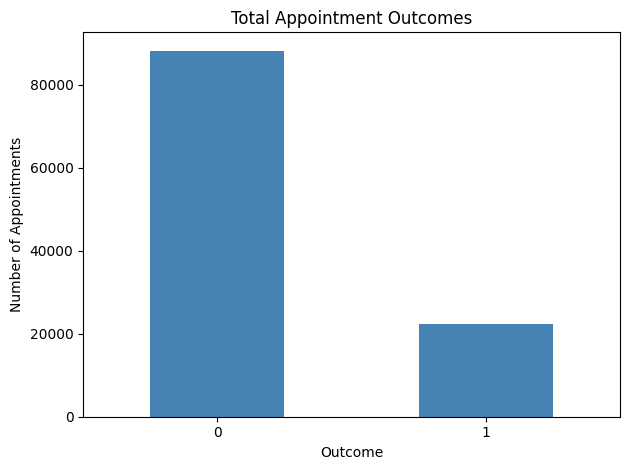

In [20]:
plot_noshowrate_counts = df_1['No_Show'].value_counts()
plot_noshowrate_counts.plot(kind='bar', color='steelblue')
plt.title('Total Appointment Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Now that we have an idea of the total number of appointment outcomes, we'll want to look at lead times for those that showed vs didn't. Lead time will be defined as the number of days out that the appointment was scheduled. We also want to be on the lookout for negative lead times. 

In [21]:
df_1['ScheduledDay'] = pd.to_datetime(df_1['ScheduledDay'])
df_1['AppointmentDay'] = pd.to_datetime(df_1['AppointmentDay'])
df_1['LeadTime'] = (df_1['AppointmentDay'] - df_1['ScheduledDay']).dt.days

In [22]:
print(df_1['LeadTime'].describe())
print(f"\nNegative lead times: {(df_1['LeadTime'] < 0).sum()}")
negative_count = (df_1['LeadTime'] < 0).sum()
total_count = len(df_1)
print(f"Percentage of dataset: {negative_count/total_count*100:.2f}%")

count    110526.000000
mean          9.183794
std          15.255034
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: LeadTime, dtype: float64

Negative lead times: 38567
Percentage of dataset: 34.89%


In [23]:
print(df_1[df_1['LeadTime'] < 0]['LeadTime'].value_counts().head(10))

-1    38562
-2        4
-7        1
Name: LeadTime, dtype: int64


Majority of the lead time values are -1, which shouldn't be possible. It is possible, however, that they are scheduled for the same day but have different times. If that is the case, then we'd want to trim them to be 0, since an appointment scheduled the same day would have a lead time of 0. Our median will shift, but this should be a better alternative rather than dropping 1/3 of the dataset!

In [24]:
df_1['LeadTime'] = df_1['LeadTime'].clip(lower=0)

In [25]:
print(f"Negative lead times remaining: {(df_1['LeadTime'] < 0).sum()}")
print(df_1['LeadTime'].describe())

Negative lead times remaining: 0
count    110526.000000
mean          9.532825
std          15.027769
min           0.000000
25%           0.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: LeadTime, dtype: float64


In [26]:
# We can also use the following to get the percentiles.This also helps give context that the lead times are measured in days!
print(f"Lead Time Percentiles:")
print(f"25th: {np.percentile(df_1['LeadTime'], 25):.1f} days")
print(f"50th: {np.percentile(df_1['LeadTime'], 50):.1f} days")
print(f"75th: {np.percentile(df_1['LeadTime'], 75):.1f} days")
print(f"90th: {np.percentile(df_1['LeadTime'], 90):.1f} days")

Lead Time Percentiles:
25th: 0.0 days
50th: 3.0 days
75th: 14.0 days
90th: 29.0 days


Few interesting things to note regarding the data: the average lead time is ~9.53 days, but the max is 178 days. This maximum is most likely an outlier, meaning the data is skewed. 20% of appointments are scheduled that same day. 50% of all appointments are 3 days out. Nearly 75% of all apointments are two weeks out. A visual will help to show how the data is skewed.

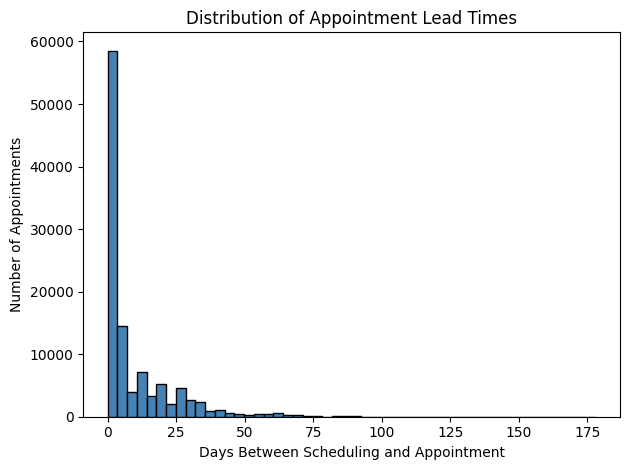

In [38]:
#a univariate comparison showing the overall distribution of appointment lead-Times
plt.hist(df_1['LeadTime'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Appointment Lead Times')
plt.xlabel('Days Between Scheduling and Appointment')
plt.ylabel('Number of Appointments')
plt.tight_layout()
plt.show()

Now that we have an idea of the appointment lead times, we'll organize the data into bins, get the no show rate by lead time, and plot it!

In [29]:
df_1['LeadTimeBin'] = pd.cut(df_1['LeadTime'],bins=[-1, 0, 7, 14, 30, 60, 178],labels=['Same Day', '1-7 Days', '8-14 Days', '15-30 Days', '31-60 Days', '60+ Days'])

In [30]:
print(df_1['LeadTimeBin'].value_counts().sort_index())

Same Day      43780
1-7 Days      29304
8-14 Days     11196
15-30 Days    16540
31-60 Days     7746
60+ Days       1960
Name: LeadTimeBin, dtype: int64


In [31]:
leadtime_noshowrate = df_1.groupby('LeadTimeBin', observed=True)['No_Show'].mean() * 100
print("No-Show Rate by Lead Time Bin:")
print(leadtime_noshowrate.round(2))

No-Show Rate by Lead Time Bin:
LeadTimeBin
Same Day       6.65
1-7 Days      25.01
8-14 Days     31.23
15-30 Days    32.52
31-60 Days    34.08
60+ Days      28.83
Name: No_Show, dtype: Float64


Right now its pretty clear that as lead time increases, the now show rate also steadily increases. I, however, prefer visualizations when looking at data. It can be hard to visualize in my head how its increasing, so a graph helps.

In [32]:
#Function to plot more graphs
def plot_noshowrate(data, group_col, title, xlabel, ylabel='No-Show Rate %', color='steelblue'):
    rates = data.groupby(group_col, observed=True)['No_Show'].mean() * 100
    ax = rates.plot(kind='bar', color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

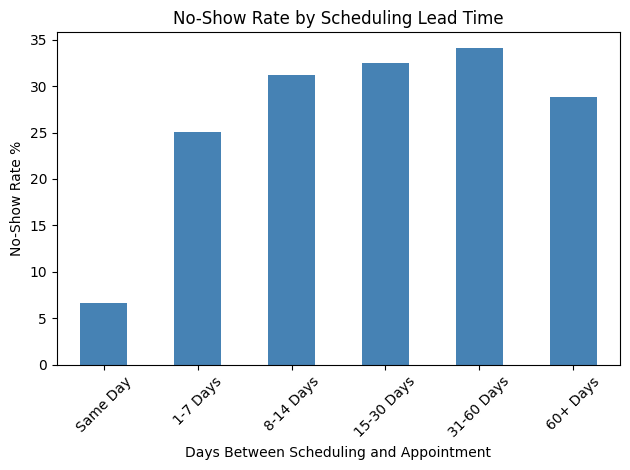

In [33]:
#This is a bivariate comparison between the No-Show Rate and Lead-Time.
plot_noshowrate(df_1,'LeadTimeBin','No-Show Rate by Scheduling Lead Time','Days Between Scheduling and Appointment')

While not strictly required to answer the first question, for those that are curious I've added a 'No-Show Rate by Gender' visual. This helps us compare how the No-Show rate is divided by Gender.

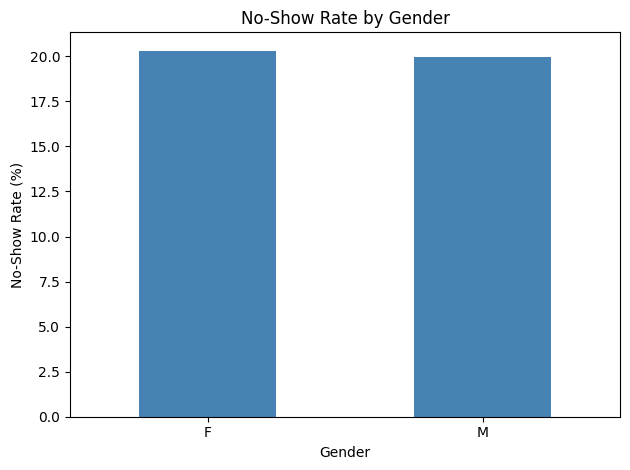

Gender
F    20.31
M    19.97
Name: No_Show, dtype: Float64


In [36]:
#another bivariate comparison.
gender_noshow = df_1.groupby('Gender')['No_Show'].mean() * 100

gender_noshow.plot(kind='bar', color='steelblue')
plt.title('No-Show Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(gender_noshow.round(2))

as you can see in the above, both genders are around ~20% for the no-show rate. Gender alone does not appear to be a strong indicator as to whether an individual no shows.

### Does the SMS reminder affect whether a patient shows for their appointment or not?

Before diving in, we'll want to get an idea of the total 'SMS_received' counts. The following chart helps us visually see the totals.

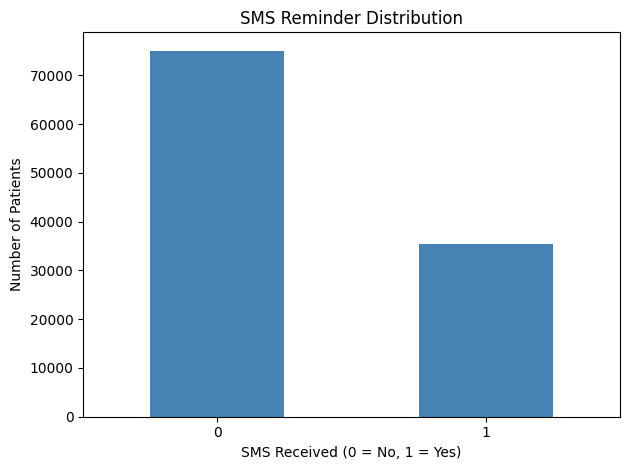

In [34]:
df_1['SMS_received'].value_counts().plot(kind='bar', color='steelblue')
plt.title('SMS Reminder Distribution')
plt.xlabel('SMS Received (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

We already have the number of showed appointments vs no-showed appointments. Now we can begin looking at the number of appointments that had an SMS reminder vs not, and the number of appointments that no-showed that had an SMS reminder vs not. 

In [43]:
sms_noshowcounts = df_1.groupby(['SMS_received', 'No_Show'], observed=True).size().unstack()
print(sms_noshowcounts)

No_Show           0      1
SMS_received              
0             62509  12535
1             25698   9784


Already the raw counts are interesting. There are more patients that didn't receive SMS compared to those that did. While it seems like more people showed up that didn't receive SMS at face value, the rates will give a clearer picture into whether SMS played a role. 

In [44]:
sms_noshowrate = df_1.groupby('SMS_received', observed=True)['No_Show'].mean() * 100
print(sms_noshowrate.round(2))

SMS_received
0     16.7
1    27.57
Name: No_Show, dtype: Float64


On first glance it looks like the percentage of SMS received, however this is an incorrect reading. Since we're grouping by 'SMS_received', then calculating the mean by No_Show, this is what we're actually looking at:
- Patients who did not receive an SMS had a 16.70% no-show rate
- Patients who did receive an SMS had a 27.57% no-show rate

The following script will get us an idea the percentage of patients who received SMS:

In [45]:
print((df_1['SMS_received'].value_counts(normalize=True) * 100).round(3))

0    67.897
1    32.103
Name: SMS_received, dtype: float64


The following is a graph of the no-show rate by SMS reminder.

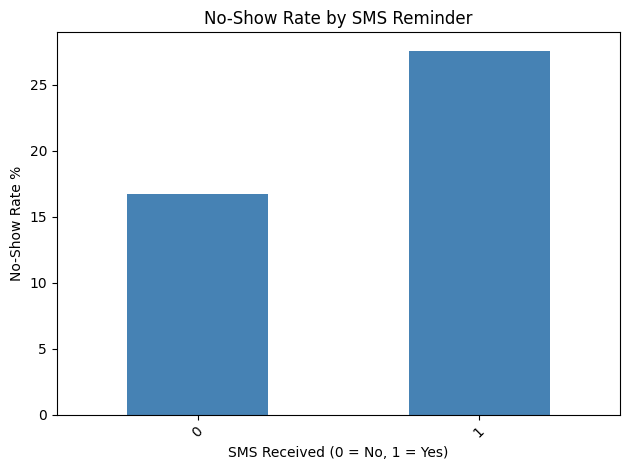

In [46]:
plot_noshowrate(df_1, 'SMS_received','No-Show Rate by SMS Reminder','SMS Received (0 = No, 1 = Yes)')



<a id='conclusions'></a>
## Conclusions

Same-day appointments had the lowest no-show rate at 6.65%, rising sharply to 25.01% for appointments scheduled 1-7 days in advance, and continuing to climb to a peak of 34.08% for appointments scheduled 31-60 days out. This suggests that patient commitment to an appointment weakens as the scheduled date feels more distant. We would want to explore other factors to see if anything else also affects whether a patient shows for their scheduled appointment.

Initially, one would think that those who had an SMS reminder would show more for their appointments. However, Patients who received an SMS reminder had a higher no-show rate (27.57%) than those who did not (16.70%).This finding should not be interpreted as evidence that SMS reminders increase no-shows. A more plausible explanation (but ultimately a guess) is that those who received SMS reminders were already late for their appointment. The data set does lack any information regarding SMS reminder cadence and what days/times the reminder was sent, making it difficult to draw conclusions at present.

## Limitations

The following isn't meant to be a comprehensive list, but rather a brief summary of the limitations with the current dataset we're working with:
- Neighborhood distance from the clinic is unknown. If the distance is too great, it may affect whether a patient shows for their appointment or not. We could look to see if certain neighborhoods tend to have higher no-show rates compared to others, but that would be a guess without more data.
- We do not know when the SMS was sent, making it hard to validate the possible explanation proposed that those who got SMS reminders were already late for their appointment. Having listed the date and time of when an SMS was sent would provide insight into how the SMS cadence could be updated to improve the rate that patients show for an appointment.
- The analysis is only looking at lead times and SMS reminders compared to the no-show rate. We have not considered if other confounding variables are contributing to whether a patient shows for their appointment. (A good example would be if those that have underlying health conditions have a higher no-show rate vs those without, and seeing if the rates line up with our current rates). 

In [39]:
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 549443 bytes to Investigate_a_Dataset.html
